In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    StratifiedKFold,
    learning_curve
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    ConfusionMatrixDisplay
)

df = pd.read_csv("train.csv")

print("Shape:")
print(df.shape)

print("\nInfo:")
print(df.info())

print("\nDescribe:")
print(df.describe())

y = df["Survived"]

print("\nClass Balance:")
print(y.value_counts(normalize=True))

imbalance_ratio = y.value_counts(normalize=True)

print("\nImbalance Ratio:")
print(imbalance_ratio)

Shape:
(891, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Describe:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.5230

### Class Imbalance Ratio

Class 0 Ratio: 0.616

Class 1 Ratio: 0.383

The dataset is moderately imbalanced because the majority class has a higher percentage than the minority class.

In [3]:
df = pd.read_csv("train.csv")

df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

df["Fare"] = np.log1p(df["Fare"])

df["Sex"] = df["Sex"].map({
    "male": 1,
    "female": 0
})

df = df.drop(
    columns=[
        "Cabin",
        "PassengerId",
        "Name",
        "Ticket"
    ]
)

df = pd.get_dummies(
    df,
    columns=["Embarked"],
    drop_first=True
)

print("Final Shape:")
print(df.shape)

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nColumns:")
print(df.columns)

Final Shape:
(891, 11)

Total Missing Values:
0

Columns:
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


### Preprocessing Summary

- Filled missing Age values using median
- Filled missing Embarked values using mode
- Dropped Cabin, PassengerId, Name, and Ticket
- Encoded Sex column
- Applied one-hot encoding on Embarked
- Created FamilySize feature
- Created IsAlone feature
- Applied log1p transformation on Fare
- No missing values remain in the dataset

In [4]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Class Balance:")
print(y_train.value_counts(normalize=True))

print("\nTest Class Balance:")
print(y_test.value_counts(normalize=True))

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nMean of Scaled Train Data:")
print(X_train_scaled.mean())

print("\nStd of Scaled Train Data:")
print(X_train_scaled.std())

Train Class Balance:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Test Class Balance:
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64

Mean of Scaled Train Data:
4.5781106745778925e-17

Std of Scaled Train Data:
1.0


### Why stratify=y is Important

Using stratify=y ensures that both training and testing datasets maintain the same class distribution as the original dataset. This is critical for imbalanced classification problems because it prevents one class from being overrepresented or underrepresented in either split, leading to more reliable model evaluation.

In [5]:
results = []

def evaluate_model(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str,
    n_features: int
) -> dict:

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    n = len(y_true)

    adjusted_r2 = 1 - (
        (1 - r2) * (n - 1) / (n - n_features - 1)
    )

    mape = np.mean(
        np.abs((y_true - y_pred) / (y_true + 1e-10))
    ) * 100

    result = {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted_R2": adjusted_r2,
        "MAPE": mape
    }

    results.append(result)

    print(f"\n{model_name}")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}")
    print(f"Adjusted R2: {adjusted_r2:.4f}")
    print(f"MAPE: {mape:.4f}")

    return result


def plot_actual_vs_predicted(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str
) -> None:

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    plt.figure(figsize=(6, 6))

    plt.scatter(y_true, y_pred)

    plt.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        linewidth=2
    )

    plt.xlabel("Actual")

    plt.ylabel("Predicted")

    plt.title(f"{model_name} Actual vs Predicted")

    plt.text(
        0.05,
        0.90,
        f"R2 = {r2:.4f}",
        transform=plt.gca().transAxes
    )

    plt.text(
        0.05,
        0.84,
        f"RMSE = {rmse:.4f}",
        transform=plt.gca().transAxes
    )

    plt.show()

### Utility Functions

- evaluate_model() computes MAE, MSE, RMSE, R², Adjusted R², and MAPE
- plot_actual_vs_predicted() visualizes actual and predicted values using a scatter plot
- Both functions are reusable for all models


Logistic Regression Train
MAE: 0.2037
MSE: 0.2037
RMSE: 0.4513
R2: 0.1386
Adjusted R2: 0.1263
MAPE: 91292134842.6966

Logistic Regression Test
MAE: 0.1788
MSE: 0.1788
RMSE: 0.4228
R2: 0.2453
Adjusted R2: 0.2004
MAPE: 67039106156.4246

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       110
           1       0.80      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



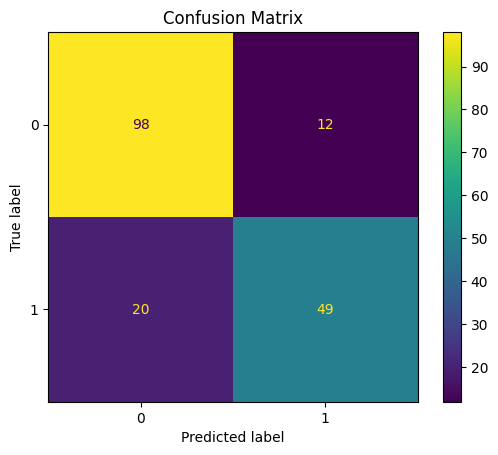

In [6]:
model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)

y_test_pred = model.predict(X_test_scaled)

evaluate_model(
    y_train,
    y_train_pred,
    "Logistic Regression Train",
    X_train.shape[1]
)

evaluate_model(
    y_test,
    y_test_pred,
    "Logistic Regression Test",
    X_test.shape[1]
)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

      Feature  Coefficient
1         Sex     1.226255
0      Pclass     0.725153
2         Age     0.498059
5        Fare     0.366844
3       SibSp     0.321390
6  FamilySize     0.260763
7     IsAlone     0.244882
8  Embarked_Q     0.117592
9  Embarked_S     0.106621
4       Parch     0.087646


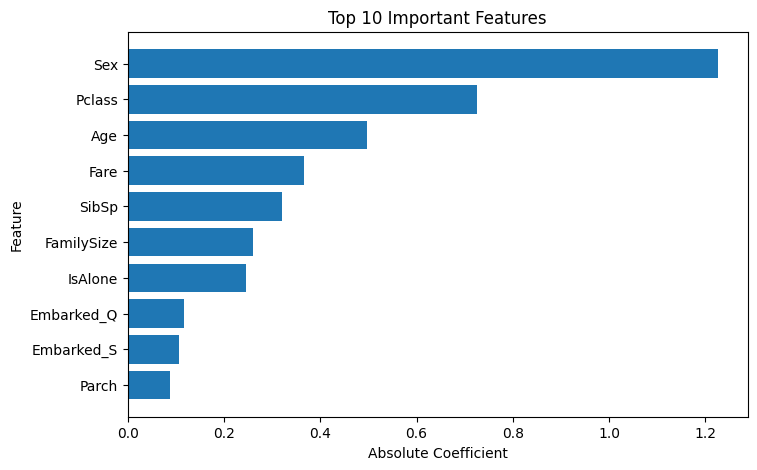

In [7]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": np.abs(model.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

print(feature_importance)

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Coefficient"]
)

plt.xlabel("Absolute Coefficient")

plt.ylabel("Feature")

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [8]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for t in thresholds:

    y_pred_thresh = (y_prob >= t).astype(int)

    precision = precision_score(
        y_test,
        y_pred_thresh
    )

    recall = recall_score(
        y_test,
        y_pred_thresh
    )

    f1 = f1_score(
        y_test,
        y_pred_thresh
    )

    print(f"\nThreshold: {t}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall: {recall:.4f}")

    print(f"F1 Score: {f1:.4f}")


Threshold: 0.3
Precision: 0.6667
Recall: 0.8116
F1 Score: 0.7320

Threshold: 0.4
Precision: 0.7222
Recall: 0.7536
F1 Score: 0.7376

Threshold: 0.5
Precision: 0.8033
Recall: 0.7101
F1 Score: 0.7538

Threshold: 0.6
Precision: 0.8627
Recall: 0.6377
F1 Score: 0.7333

Threshold: 0.7
Precision: 0.9000
Recall: 0.5217
F1 Score: 0.6606


### Best Threshold for F1 Score

The threshold with the best F1 score is 0.5 because it provides the best balance between Precision and Recall.

### Why Lower Thresholds are Preferred in Disease Detection

A lower threshold increases Recall, which helps detect more positive cases. In disease detection, missing a true positive can be dangerous, so higher Recall is usually preferred even if Precision decreases.

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_results = []

k_values = range(1, 31)

for k in k_values:

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    knn_results.append({
        "K": k,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

knn_df = pd.DataFrame(knn_results)

print(knn_df)

best_k = knn_df.loc[
    knn_df["F1"].idxmax(),
    "K"
]

print("\nBest K:", best_k)

     K  Accuracy  Precision    Recall        F1
0    1  0.709497   0.623188  0.623188  0.623188
1    2  0.754190   0.804878  0.478261  0.600000
2    3  0.782123   0.727273  0.695652  0.711111
3    4  0.804469   0.840000  0.608696  0.705882
4    5  0.782123   0.734375  0.681159  0.706767
5    6  0.804469   0.840000  0.608696  0.705882
6    7  0.782123   0.741935  0.666667  0.702290
7    8  0.793296   0.796296  0.623188  0.699187
8    9  0.798883   0.779661  0.666667  0.718750
9   10  0.810056   0.843137  0.623188  0.716667
10  11  0.793296   0.775862  0.652174  0.708661
11  12  0.826816   0.880000  0.637681  0.739496
12  13  0.837989   0.857143  0.695652  0.768000
13  14  0.837989   0.900000  0.652174  0.756303
14  15  0.826816   0.827586  0.695652  0.755906
15  16  0.826816   0.865385  0.652174  0.743802
16  17  0.826816   0.827586  0.695652  0.755906
17  18  0.832402   0.867925  0.666667  0.754098
18  19  0.826816   0.839286  0.681159  0.752000
19  20  0.804469   0.826923  0.623188  0

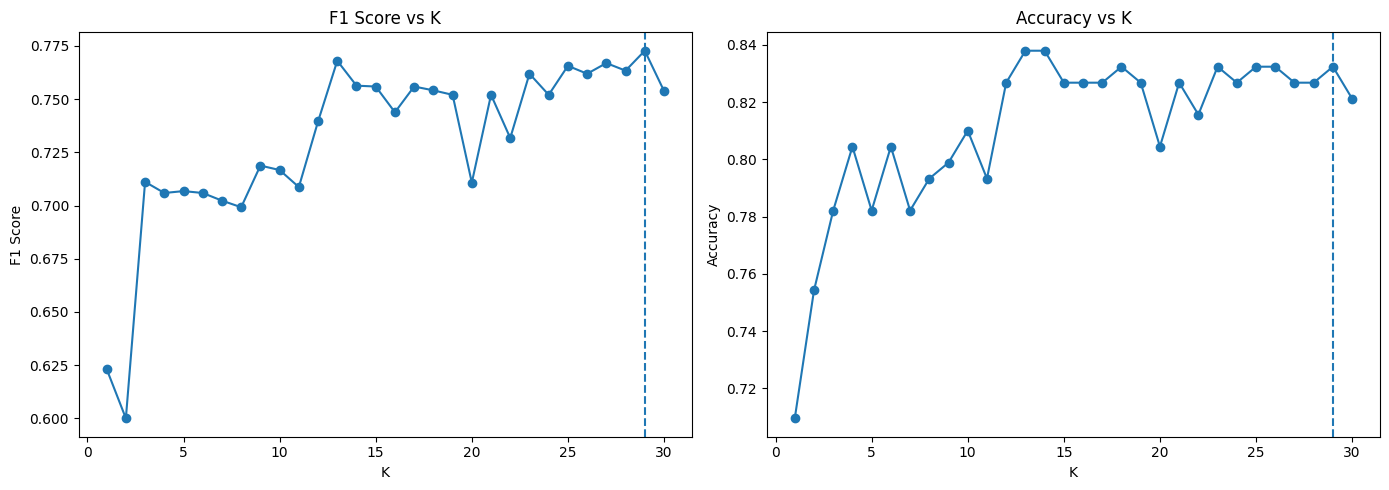

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(
    knn_df["K"],
    knn_df["F1"],
    marker="o"
)

ax[0].axvline(
    best_k,
    linestyle="--"
)

ax[0].set_xlabel("K")

ax[0].set_ylabel("F1 Score")

ax[0].set_title("F1 Score vs K")

ax[1].plot(
    knn_df["K"],
    knn_df["Accuracy"],
    marker="o"
)

ax[1].axvline(
    best_k,
    linestyle="--"
)

ax[1].set_xlabel("K")

ax[1].set_ylabel("Accuracy")

ax[1].set_title("Accuracy vs K")

plt.tight_layout()

plt.show()

In [11]:
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    {
        "n_neighbors": range(1, 30)
    },
    cv=5,
    scoring="f1"
)

grid_knn.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_knn.best_params_)

print("\nBest CV F1:")
print(grid_knn.best_score_)

Best Parameters:
{'n_neighbors': 3}

Best CV F1:
0.7569844129016564


In [12]:
metrics_results = []

distance_metrics = [
    "euclidean",
    "manhattan",
    "minkowski"
]

for metric in distance_metrics:

    knn_metric = KNeighborsClassifier(
        n_neighbors=best_k,
        metric=metric
    )

    knn_metric.fit(X_train_scaled, y_train)

    y_pred = knn_metric.predict(X_test_scaled)

    y_prob = knn_metric.predict_proba(X_test_scaled)[:, 1]

    f1 = f1_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_prob)

    metrics_results.append({
        "Metric": metric,
        "F1": f1,
        "AUC": auc
    })

metrics_df = pd.DataFrame(metrics_results)

print(metrics_df)

      Metric        F1       AUC
0  euclidean  0.772727  0.830501
1  manhattan  0.725926  0.819499
2  minkowski  0.772727  0.830501


### KNN Distance Metric Comparison

The best distance metric is euclidean and minkowski because it achieved the highest F1-score and ROC-AUC value.

GridSearchCV confirmed the optimal value of K as 3 .

In [13]:
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree,
    export_text
)

depth_results = []

for depth in [2, 3, 5, 7, 10, None]:

    dt = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    dt.fit(X_train_scaled, y_train)

    train_acc = dt.score(
        X_train_scaled,
        y_train
    )

    test_acc = dt.score(
        X_test_scaled,
        y_test
    )

    gap = train_acc - test_acc

    depth_results.append({
        "Depth": depth,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Gap": gap
    })

    print(
        f"depth={depth} "
        f"train={train_acc:.4f} "
        f"test={test_acc:.4f} "
        f"gap={gap:.4f}"
    )

depth_df = pd.DataFrame(depth_results)

print(depth_df)


depth=2 train=0.8048 test=0.7598 gap=0.0450
depth=3 train=0.8287 test=0.8045 gap=0.0242
depth=5 train=0.8638 test=0.7654 gap=0.0984
depth=7 train=0.8876 test=0.7598 gap=0.1279
depth=10 train=0.9284 test=0.7709 gap=0.1574
depth=None train=0.9817 test=0.7709 gap=0.2108
   Depth  Train Accuracy  Test Accuracy       Gap
0    2.0        0.804775       0.759777  0.044999
1    3.0        0.828652       0.804469  0.024182
2    5.0        0.863764       0.765363  0.098401
3    7.0        0.887640       0.759777  0.127864
4   10.0        0.928371       0.770950  0.157421
5    NaN        0.981742       0.770950  0.210792


In [14]:
dt_cv = GridSearchCV(
    DecisionTreeClassifier(
        random_state=42
    ),
    {
        "max_depth": range(2, 15)
    },
    cv=5,
    scoring="f1"
)

dt_cv.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(dt_cv.best_params_)

print("\nBest CV F1:")
print(dt_cv.best_score_)

Best Parameters:
{'max_depth': 6}

Best CV F1:
0.7367861217268561


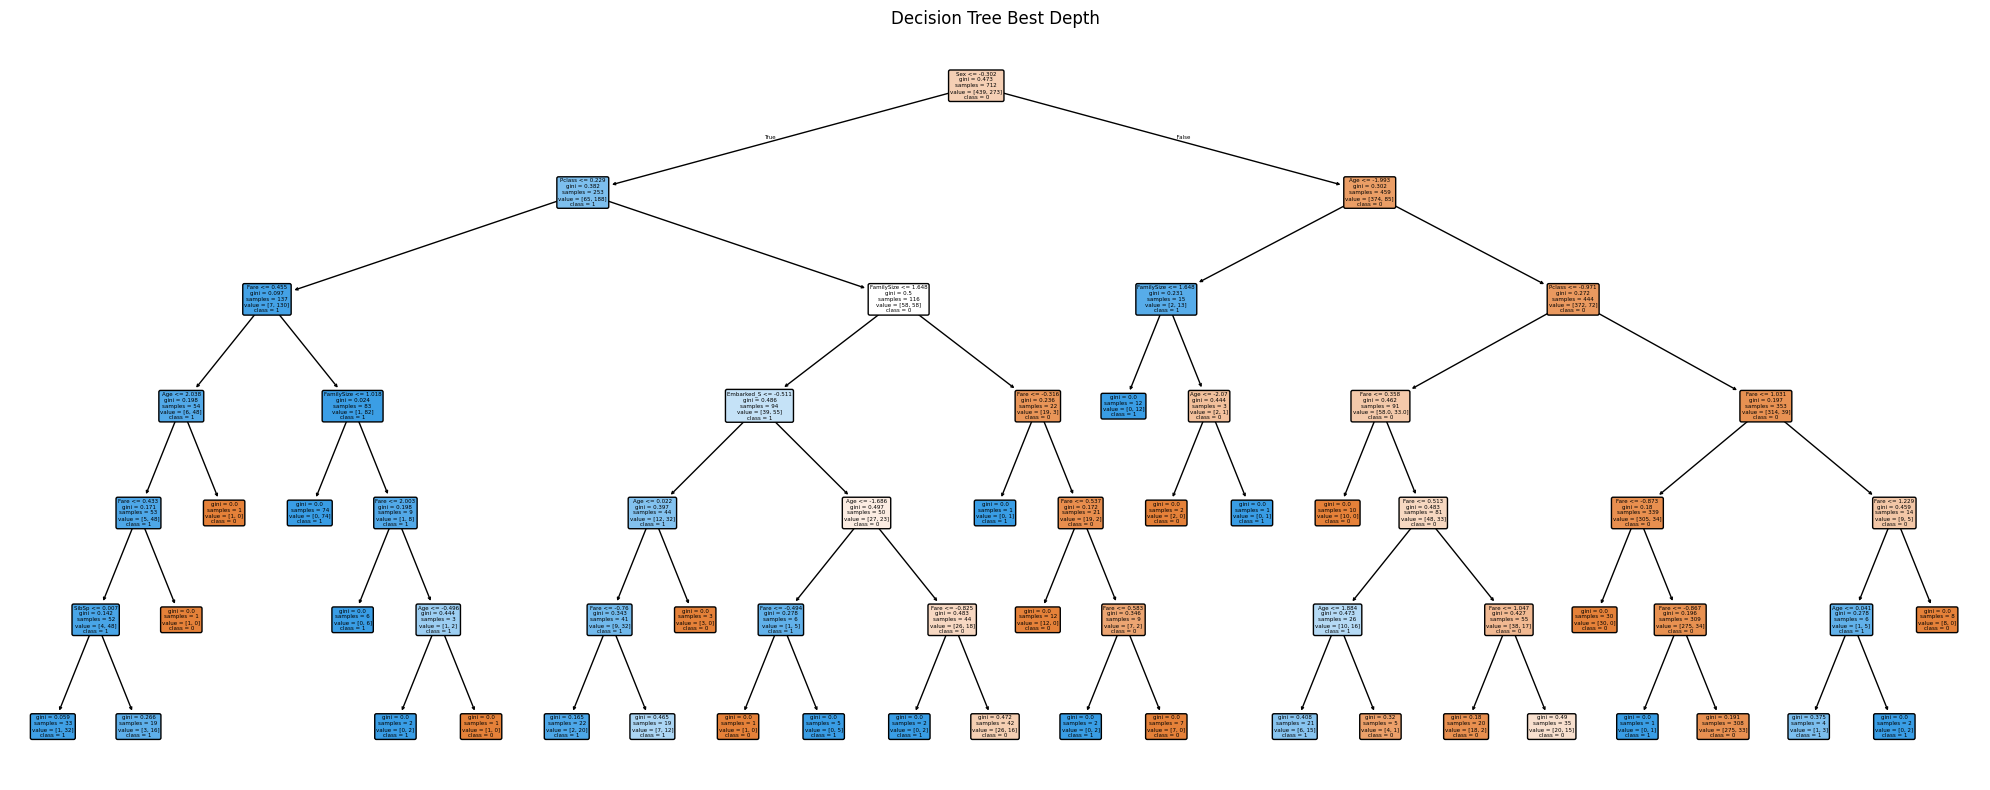

In [15]:
fig, ax = plt.subplots(
    figsize=(20, 8)
)

plot_tree(
    dt_cv.best_estimator_,
    feature_names=X.columns,
    class_names=["0", "1"],
    filled=True,
    rounded=True,
    ax=ax
)

plt.title("Decision Tree Best Depth")

plt.tight_layout()

plt.savefig(
    "decision_tree.png",
    dpi=150
)

plt.show()

### Decision Tree Depth Analysis

Smaller depths produced simpler trees with lower overfitting, while larger depths increased the gap between training and testing accuracy.

GridSearchCV selected the depth with the best cross-validation F1-score.

In [16]:
best_dt = dt_cv.best_estimator_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_dt.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(15)

print(importance_df)

      Feature  Importance
1         Sex    0.492800
0      Pclass    0.167534
5        Fare    0.147763
2         Age    0.127602
6  FamilySize    0.046166
9  Embarked_S    0.016230
3       SibSp    0.001906
4       Parch    0.000000
7     IsAlone    0.000000
8  Embarked_Q    0.000000


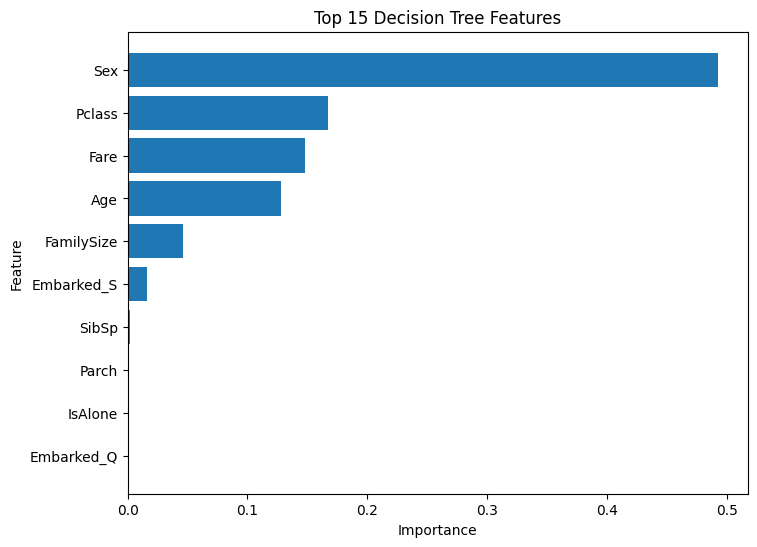

In [17]:
plt.figure(figsize=(8, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Top 15 Decision Tree Features")

plt.gca().invert_yaxis()

plt.show()

In [18]:
depths = range(1, 15)

train_f1 = []

test_f1 = []

for d in depths:

    model = DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)

    test_pred = model.predict(X_test_scaled)

    train_f1.append(
        f1_score(y_train, train_pred)
    )

    test_f1.append(
        f1_score(y_test, test_pred)
    )

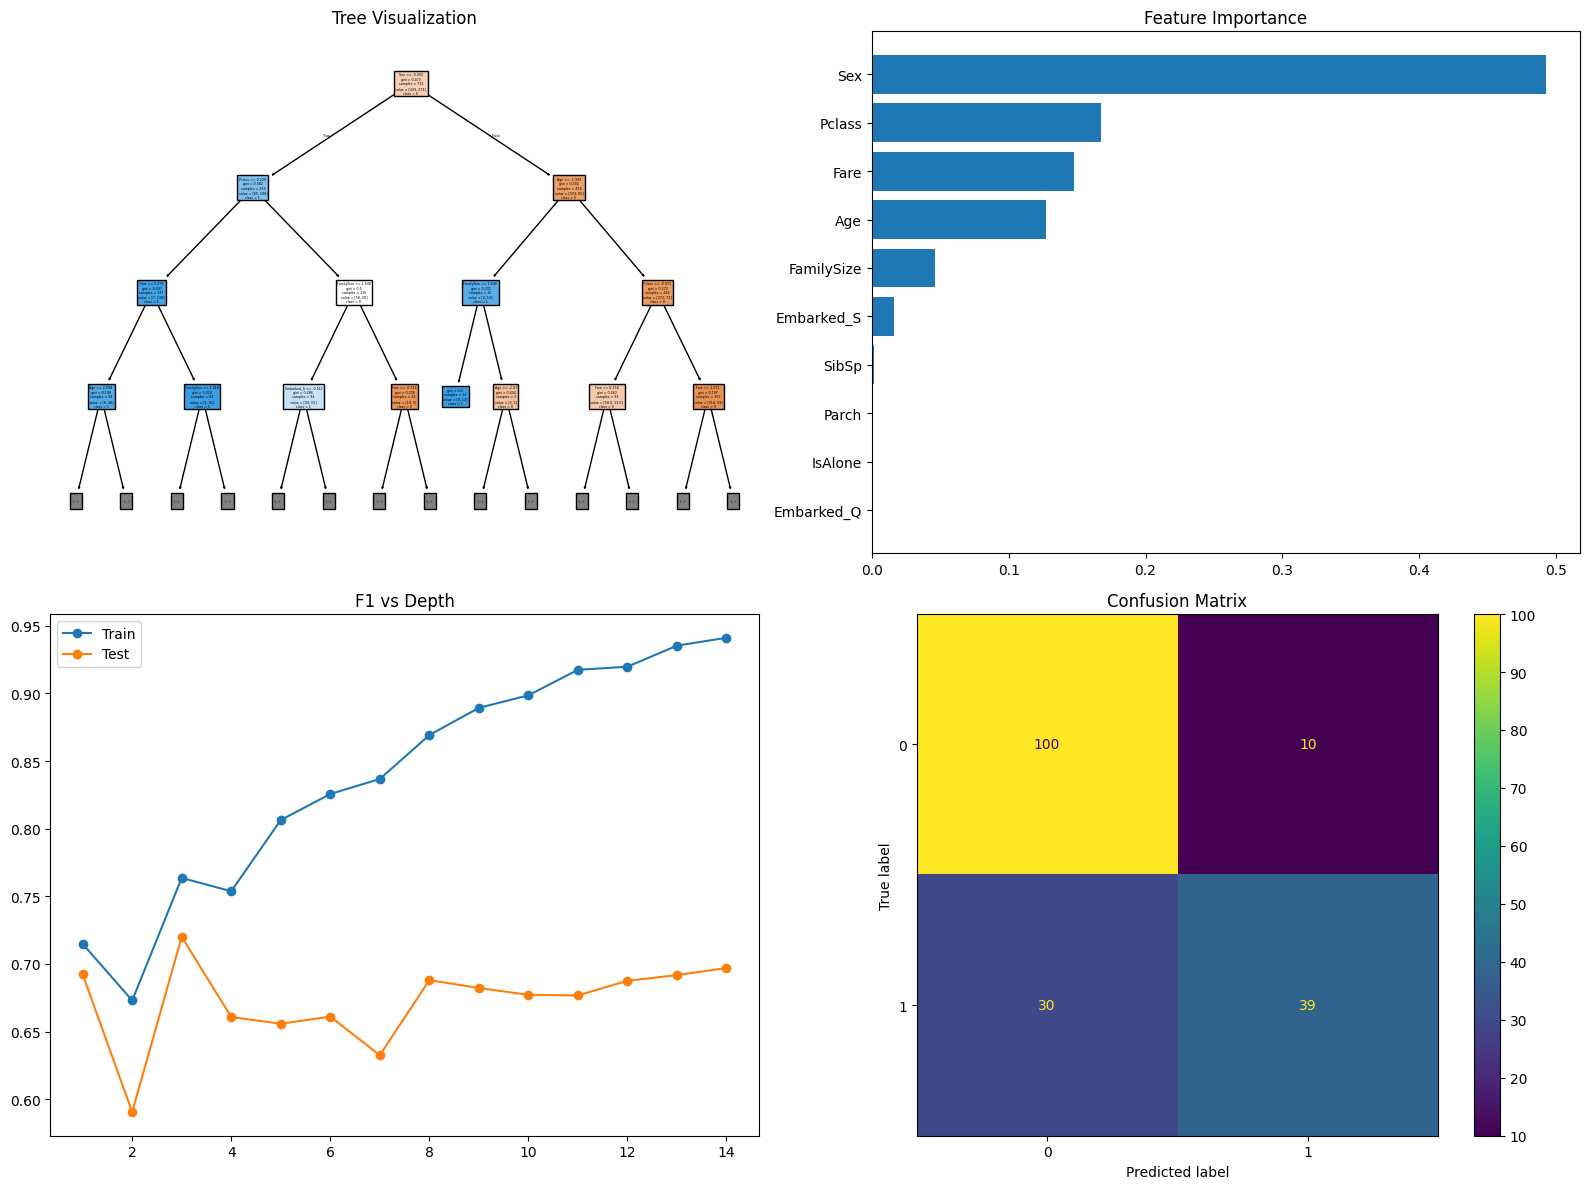

In [19]:
fig, ax = plt.subplots(
    2,
    2,
    figsize=(16, 12)
)

plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=["0", "1"],
    filled=True,
    max_depth=3,
    ax=ax[0, 0]
)

ax[0, 0].set_title("Tree Visualization")

ax[0, 1].barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

ax[0, 1].invert_yaxis()

ax[0, 1].set_title("Feature Importance")

ax[1, 0].plot(
    depths,
    train_f1,
    marker="o",
    label="Train"
)

ax[1, 0].plot(
    depths,
    test_f1,
    marker="o",
    label="Test"
)

ax[1, 0].legend()

ax[1, 0].set_title("F1 vs Depth")

cm = confusion_matrix(
    y_test,
    best_dt.predict(X_test_scaled)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(ax=ax[1, 1])

ax[1, 1].set_title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "decision_tree_analysis.png",
    dpi=150
)

plt.show()

### Titanic Survival Insight from First Split

The first split in the Decision Tree was based on Sex, showing that this feature had the strongest influence on passenger survival probability.

In [20]:
import time
from sklearn.ensemble import RandomForestClassifier

rf_results = []

estimators = [10, 50, 100, 200, 500]

for n in estimators:

    start = time.time()

    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    rf.fit(X_train_scaled, y_train)

    end = time.time()

    y_pred = rf.predict(X_test_scaled)

    y_prob = rf.predict_proba(X_test_scaled)[:, 1]

    f1 = f1_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_prob)

    train_time = end - start

    rf_results.append({
        "Estimators": n,
        "F1": f1,
        "AUC": auc,
        "Training Time": train_time
    })

rf_df = pd.DataFrame(rf_results)

print(rf_df)

   Estimators        F1       AUC  Training Time
0          10  0.723077  0.817194       0.040116
1          50  0.746269  0.825758       0.155711
2         100  0.776119  0.828788       0.314573
3         200  0.755556  0.824835       0.630318
4         500  0.751880  0.828524       1.232341


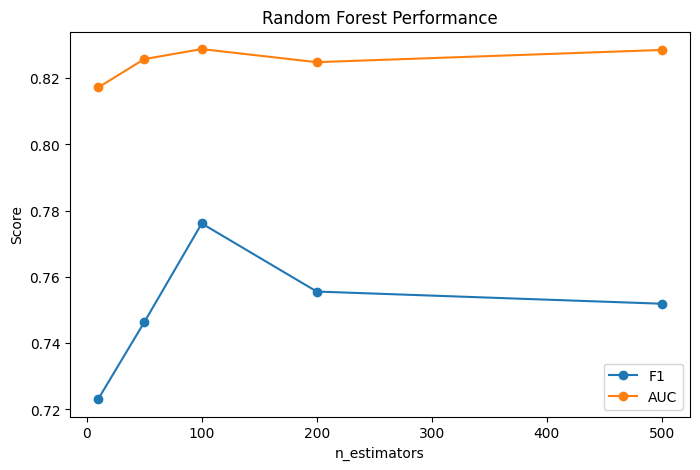

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    rf_df["Estimators"],
    rf_df["F1"],
    marker="o",
    label="F1"
)

plt.plot(
    rf_df["Estimators"],
    rf_df["AUC"],
    marker="o",
    label="AUC"
)

plt.xlabel("n_estimators")

plt.ylabel("Score")

plt.title("Random Forest Performance")

plt.legend()

plt.show()

      Feature  Importance
5        Fare    0.265504
1         Sex    0.255075
2         Age    0.245407
0      Pclass    0.088831
6  FamilySize    0.048102
3       SibSp    0.026110
9  Embarked_S    0.026071
4       Parch    0.022915
7     IsAlone    0.013012
8  Embarked_Q    0.008973


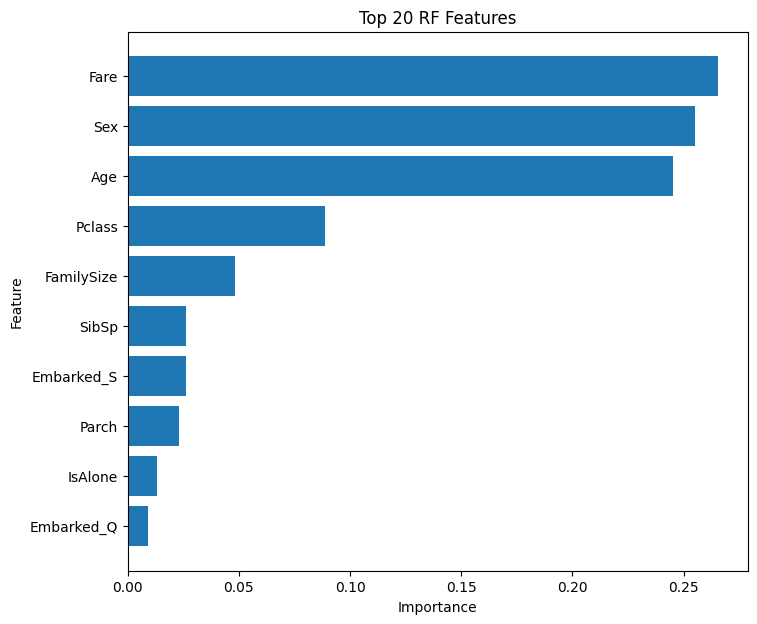

In [22]:
best_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

best_rf.fit(X_train_scaled, y_train)

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

print(rf_importance)

plt.figure(figsize=(8, 7))

plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Top 20 RF Features")

plt.gca().invert_yaxis()

plt.show()

### Random Forest Analysis

Performance improved as the number of trees increased, but after a certain point the improvement became very small while training time increased.

Random Forest and Decision Tree generally agreed on the most important survival features.

In [23]:
grid_rf = GridSearchCV(
    RandomForestClassifier(
        random_state=42
    ),
    {
        "n_estimators": [100, 200],
        "max_depth": [5, 10, None],
        "max_features": ["sqrt", "log2"],
        "min_samples_split": [2, 5]
    },
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest CV F1:")
print(grid_rf.best_score_)

Best Parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}

Best CV F1:
0.755590363101972


In [24]:
best_rf_model = grid_rf.best_estimator_

y_pred_rf = best_rf_model.predict(X_test_scaled)

y_prob_rf = best_rf_model.predict_proba(X_test_scaled)[:, 1]

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

print("Test F1:", rf_f1)

print("Test AUC:", rf_auc)

Test F1: 0.71875
Test AUC: 0.8375494071146246


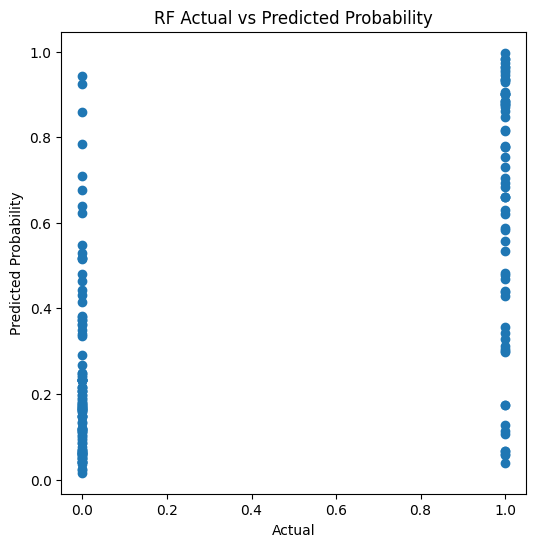

In [25]:
plt.figure(figsize=(6, 6))

plt.scatter(
    y_test,
    y_prob_rf
)

plt.xlabel("Actual")

plt.ylabel("Predicted Probability")

plt.title("RF Actual vs Predicted Probability")

plt.show()

### Random Forest Hyperparameter Tuning

GridSearchCV improved Random Forest performance by selecting the optimal combination of hyperparameters.

Random Forest achieved strong F1-score and ROC-AUC values compared to Logistic Regression and KNN.

In [26]:
comparison_results = []

models = {
    "Logistic Regression": model,
    "Best KNN": grid_knn.best_estimator_,
    "Best Decision Tree": dt_cv.best_estimator_,
    "Best Random Forest": best_rf_model
}

for name, clf in models.items():

    start = time.time()

    clf.fit(X_train_scaled, y_train)

    end = time.time()

    y_pred = clf.predict(X_test_scaled)

    y_prob = clf.predict_proba(X_test_scaled)[:, 1]

    comparison_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "Training Time": end - start
    })

comparison_df = pd.DataFrame(comparison_results)

print(comparison_df)

                 Model  Accuracy  Precision    Recall        F1       AUC  \
0  Logistic Regression  0.776536   0.730159  0.666667  0.696970  0.714493   
1             Best KNN  0.782123   0.727273  0.695652  0.711111  0.822596   
2   Best Decision Tree  0.776536   0.795918  0.565217  0.661017  0.775692   
3   Best Random Forest  0.798883   0.779661  0.666667  0.718750  0.837549   

   Training Time  
0       0.006592  
1       0.001467  
2       0.003399  
3       0.392158  


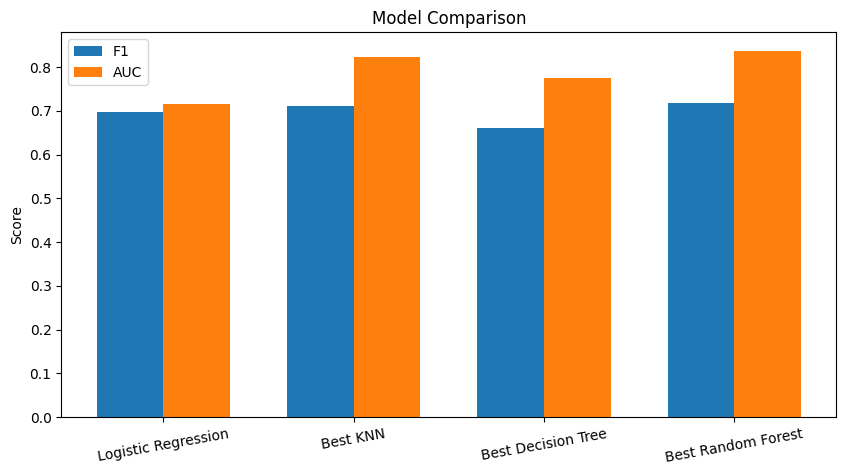

In [27]:
x = np.arange(len(comparison_df))

width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width/2,
    comparison_df["F1"],
    width,
    label="F1"
)

plt.bar(
    x + width/2,
    comparison_df["AUC"],
    width,
    label="AUC"
)

plt.xticks(
    x,
    comparison_df["Model"],
    rotation=10
)

plt.ylabel("Score")

plt.title("Model Comparison")

plt.legend()

plt.show()

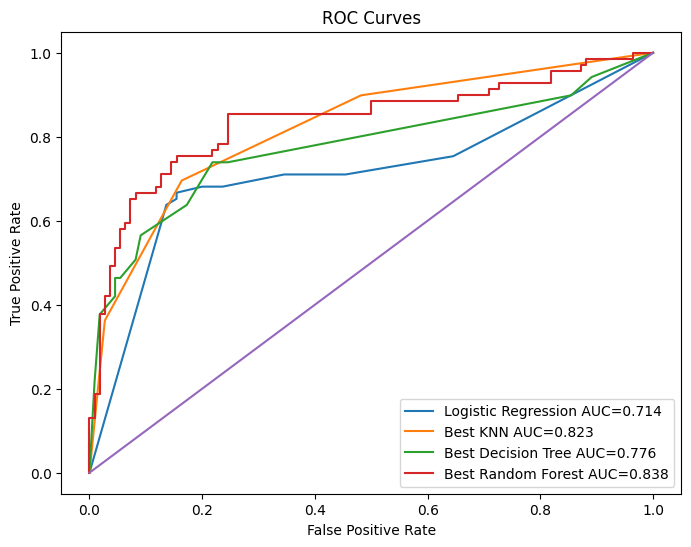

In [28]:
plt.figure(figsize=(8, 6))

for name, clf in models.items():

    y_prob = clf.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} AUC={auc:.3f}"
    )

plt.plot([0, 1], [0, 1])

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.show()

### Final Model Comparison

The best performing model was Random Forest because it achieved the highest F1-score and ROC-AUC.

The weakest model was Logistic regression and Decision Tree because it produced lower predictive performance compared to the other classifiers.

Random Forest performed well because ensemble learning reduces overfitting and improves generalization.

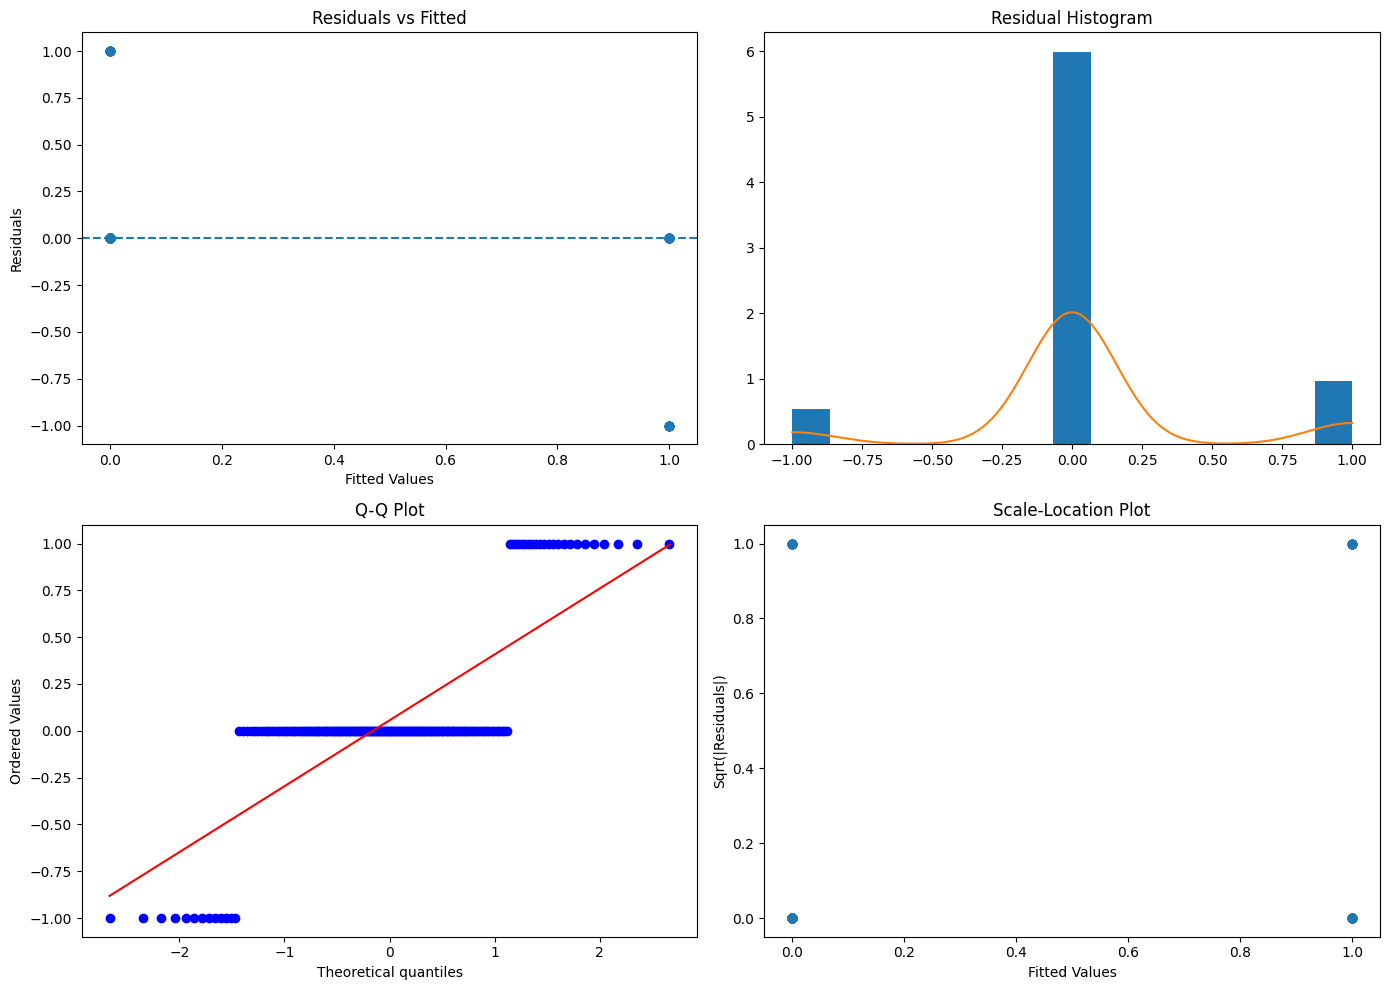

Shapiro-Wilk P-Value: 6.005568957078377e-20


In [29]:
from scipy.stats import probplot, shapiro
from scipy.stats import gaussian_kde

best_model = best_rf_model

y_pred_best = best_model.predict(X_test_scaled)

residuals = y_test - y_pred_best

fitted_values = y_pred_best

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

ax[0, 0].scatter(
    fitted_values,
    residuals
)

ax[0, 0].axhline(
    y=0,
    linestyle="--"
)

ax[0, 0].set_title("Residuals vs Fitted")

ax[0, 0].set_xlabel("Fitted Values")

ax[0, 0].set_ylabel("Residuals")

ax[0, 1].hist(
    residuals,
    bins=15,
    density=True
)

density = gaussian_kde(residuals)

x_vals = np.linspace(
    residuals.min(),
    residuals.max(),
    200
)

ax[0, 1].plot(
    x_vals,
    density(x_vals)
)

ax[0, 1].set_title("Residual Histogram")

probplot(
    residuals,
    dist="norm",
    plot=ax[1, 0]
)

ax[1, 0].set_title("Q-Q Plot")

scale_location = np.sqrt(
    np.abs(residuals)
)

ax[1, 1].scatter(
    fitted_values,
    scale_location
)

ax[1, 1].set_title("Scale-Location Plot")

ax[1, 1].set_xlabel("Fitted Values")

ax[1, 1].set_ylabel("Sqrt(|Residuals|)")

plt.tight_layout()

plt.show()

stat, p_value = shapiro(residuals)

print("Shapiro-Wilk P-Value:", p_value)

### Residual Analysis

The Shapiro-Wilk test produced a p-value of 6.005568957078377e-20.

If the p-value is less than 0.05, residuals are not normally distributed. Since this is a classification problem with binary outputs, perfectly normal residuals are generally not expected.

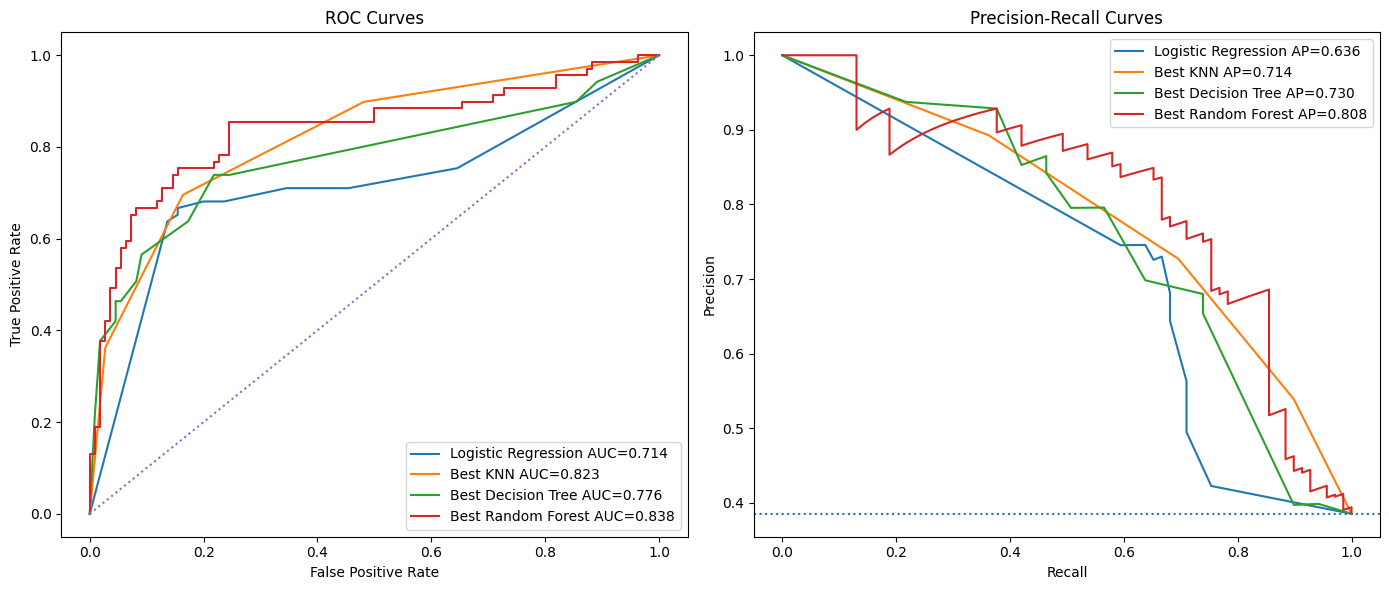

In [30]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

plt.figure(figsize=(14, 6))

ax1 = plt.subplot(1, 2, 1)

for name, clf in models.items():

    y_prob = clf.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    ax1.plot(
        fpr,
        tpr,
        label=f"{name} AUC={auc:.3f}"
    )

ax1.plot(
    [0, 1],
    [0, 1],
    linestyle=":"
)

ax1.set_title("ROC Curves")

ax1.set_xlabel("False Positive Rate")

ax1.set_ylabel("True Positive Rate")

ax1.legend()

ax2 = plt.subplot(1, 2, 2)

base_rate = y_test.mean()

for name, clf in models.items():

    y_prob = clf.predict_proba(X_test_scaled)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    ap = average_precision_score(
        y_test,
        y_prob
    )

    ax2.plot(
        recall,
        precision,
        label=f"{name} AP={ap:.3f}"
    )

ax2.axhline(
    y=base_rate,
    linestyle=":"
)

ax2.set_title("Precision-Recall Curves")

ax2.set_xlabel("Recall")

ax2.set_ylabel("Precision")

ax2.legend()

plt.tight_layout()

plt.show()

### ROC vs Precision-Recall Curves

Precision-Recall curves are more informative for imbalanced datasets because they focus directly on the performance of the positive class.

ROC curves can sometimes appear overly optimistic when the negative class is much larger than the positive class. Precision-Recall curves provide a clearer picture of how well the model identifies positive cases while controlling false positives.

Since the Titanic dataset is moderately imbalanced, the Precision-Recall curve gives better insight into classifier effectiveness for survival prediction.

In [31]:
from sklearn.pipeline import Pipeline

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

cv_f1_scores = {}

model_dict = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=best_k
    ),

    "Decision Tree": dt_cv.best_estimator_,

    "Random Forest": best_rf_model
}

for name, clf in model_dict.items():

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", clf)
    ])

    f1_scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=skf,
        scoring="f1_weighted"
    )

    auc_scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=skf,
        scoring="roc_auc"
    )

    acc_scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=skf,
        scoring="accuracy"
    )

    cv_f1_scores[name] = f1_scores

    print(f"\n{name}")

    print("F1 Scores:", f1_scores)

    print("F1 Mean:", f1_scores.mean())

    print("F1 Std:", f1_scores.std())

    print("AUC Mean:", auc_scores.mean())

    print("Accuracy Mean:", acc_scores.mean())

    cv_results.append({
        "Model": name,
        "F1 Mean": f1_scores.mean(),
        "F1 Std": f1_scores.std(),
        "AUC Mean": auc_scores.mean(),
        "Accuracy Mean": acc_scores.mean()
    })

cv_df = pd.DataFrame(cv_results)

print("\nCV Summary")
print(cv_df)


Logistic Regression
F1 Scores: [0.77710742 0.79577026 0.79319719 0.79715452 0.8143534 ]
F1 Mean: 0.7955165578174501
F1 Std: 0.011847781658657023
AUC Mean: 0.8580760074998561
Accuracy Mean: 0.7968802962776975

KNN
F1 Scores: [0.81422551 0.79047755 0.82149773 0.81376288 0.82022472]
F1 Mean: 0.8120376772760075
F1 Std: 0.011217148799405023
AUC Mean: 0.8588214941123855
Accuracy Mean: 0.8136902893729208

Decision Tree
F1 Scores: [0.82548457 0.82683216 0.73671268 0.82149773 0.81787504]
F1 Mean: 0.8056804338069504
F1 Std: 0.03462671106361269
AUC Mean: 0.8354561168123193
Accuracy Mean: 0.8103069487163392

Random Forest
F1 Scores: [0.85820767 0.82504998 0.81617528 0.83987407 0.84603023]
F1 Mean: 0.8370674463774949
F1 Std: 0.014940014735265003
AUC Mean: 0.876235104985897
Accuracy Mean: 0.8394827694432239

CV Summary
                 Model   F1 Mean    F1 Std  AUC Mean  Accuracy Mean
0  Logistic Regression  0.795517  0.011848  0.858076       0.796880
1                  KNN  0.812038  0.011217  0.

/tmp/ipykernel_522/2468506211.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


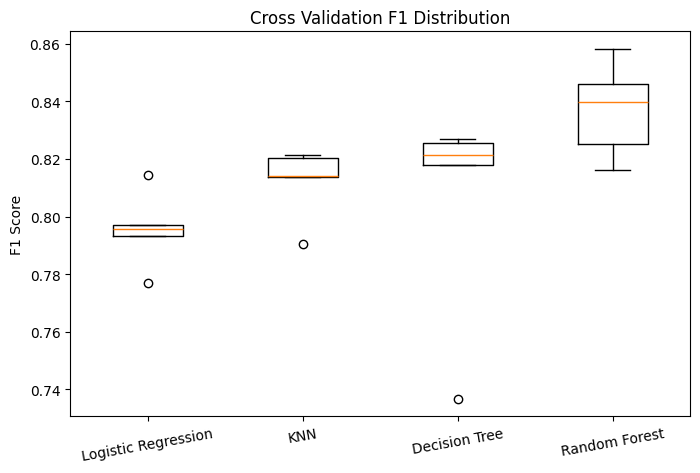

In [32]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    cv_f1_scores.values(),
    labels=cv_f1_scores.keys()
)

plt.ylabel("F1 Score")

plt.title("Cross Validation F1 Distribution")

plt.xticks(rotation=10)

plt.show()

### Cross Validation Analysis

The model with the highest mean CV F1-score was Random Forest with a mean F1-score of 0.8371.

The model with the lowest variance across folds was KNN with a standard deviation of 0.0112, showing the most stable and consistent performance.


In [33]:
from sklearn.linear_model import Ridge, Lasso

alphas = np.logspace(-3, 3, 50)

ridge_coefs = []

lasso_coefs = []

for alpha in alphas:

    ridge = Ridge(alpha=alpha)

    ridge.fit(X_train_scaled, y_train)

    ridge_coefs.append(ridge.coef_)

    lasso = Lasso(alpha=alpha)

    lasso.fit(X_train_scaled, y_train)

    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)

lasso_coefs = np.array(lasso_coefs)

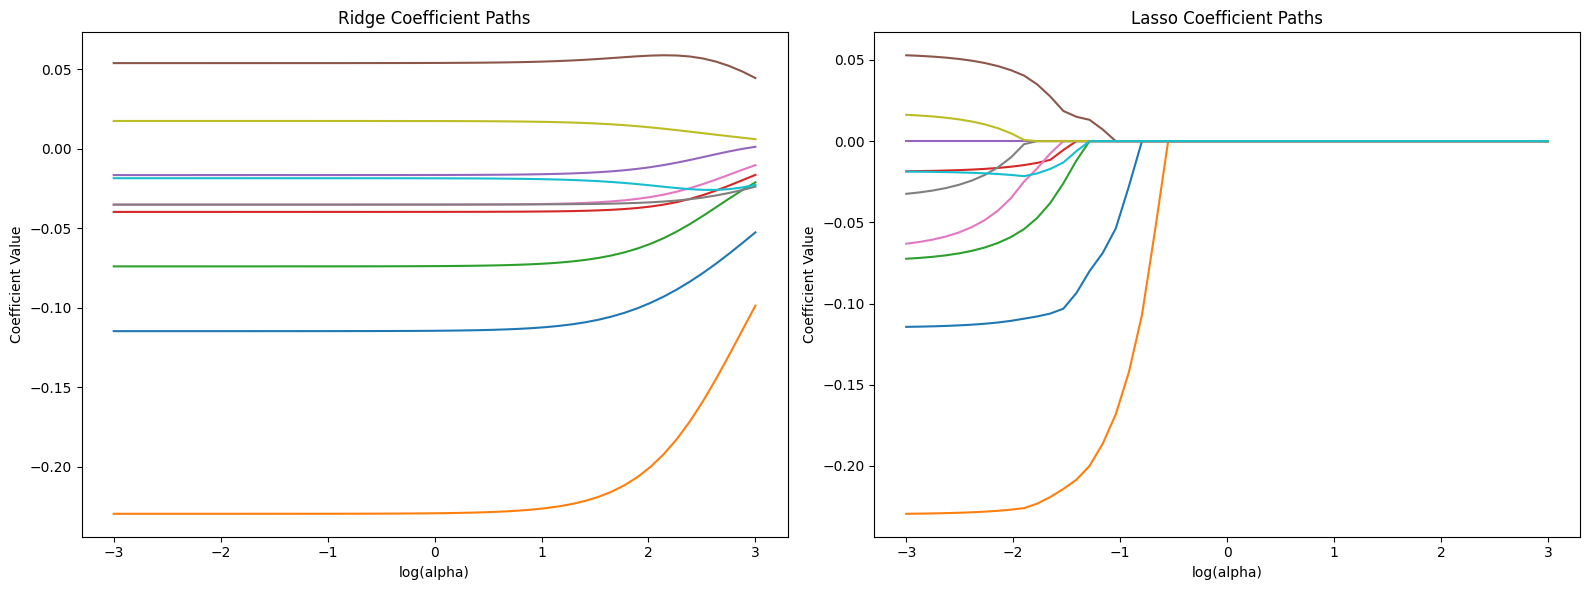

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for i in range(X.shape[1]):

    ax[0].plot(
        np.log10(alphas),
        ridge_coefs[:, i],
        label=X.columns[i]
    )

ax[0].set_title("Ridge Coefficient Paths")

ax[0].set_xlabel("log(alpha)")

ax[0].set_ylabel("Coefficient Value")

for i in range(X.shape[1]):

    ax[1].plot(
        np.log10(alphas),
        lasso_coefs[:, i],
        label=X.columns[i]
    )

ax[1].set_title("Lasso Coefficient Paths")

ax[1].set_xlabel("log(alpha)")

ax[1].set_ylabel("Coefficient Value")

plt.tight_layout()

plt.show()

In [35]:
ridge_small = pd.DataFrame(
    np.abs(ridge_coefs),
    columns=X.columns
).mean().sort_values().head(3)

lasso_zero = pd.DataFrame(
    np.abs(lasso_coefs),
    columns=X.columns
).mean().sort_values().head(3)

print("Ridge Smallest Features:")
print(ridge_small)

print("\nLasso Features Closest to Zero:")
print(lasso_zero)

Ridge Smallest Features:
Parch         0.014184
Embarked_Q    0.015850
Embarked_S    0.019923
dtype: float64

Lasso Features Closest to Zero:
Parch         0.000000
Embarked_Q    0.002220
SibSp         0.004065
dtype: float64


### Ridge and Lasso Regularization Analysis

The first features to shrink toward zero were Parch, Embarked_Q, and Embarked_S in Ridge regularization.

In Lasso regularization, the first features to reach zero were Parch, Embarked_Q, and SibSp.

This indicates that these features contributed less predictive information to the model compared to stronger survival-related features such as Sex, Pclass, Fare, and Age.

/tmp/ipykernel_522/675315776.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[2, 0].boxplot(


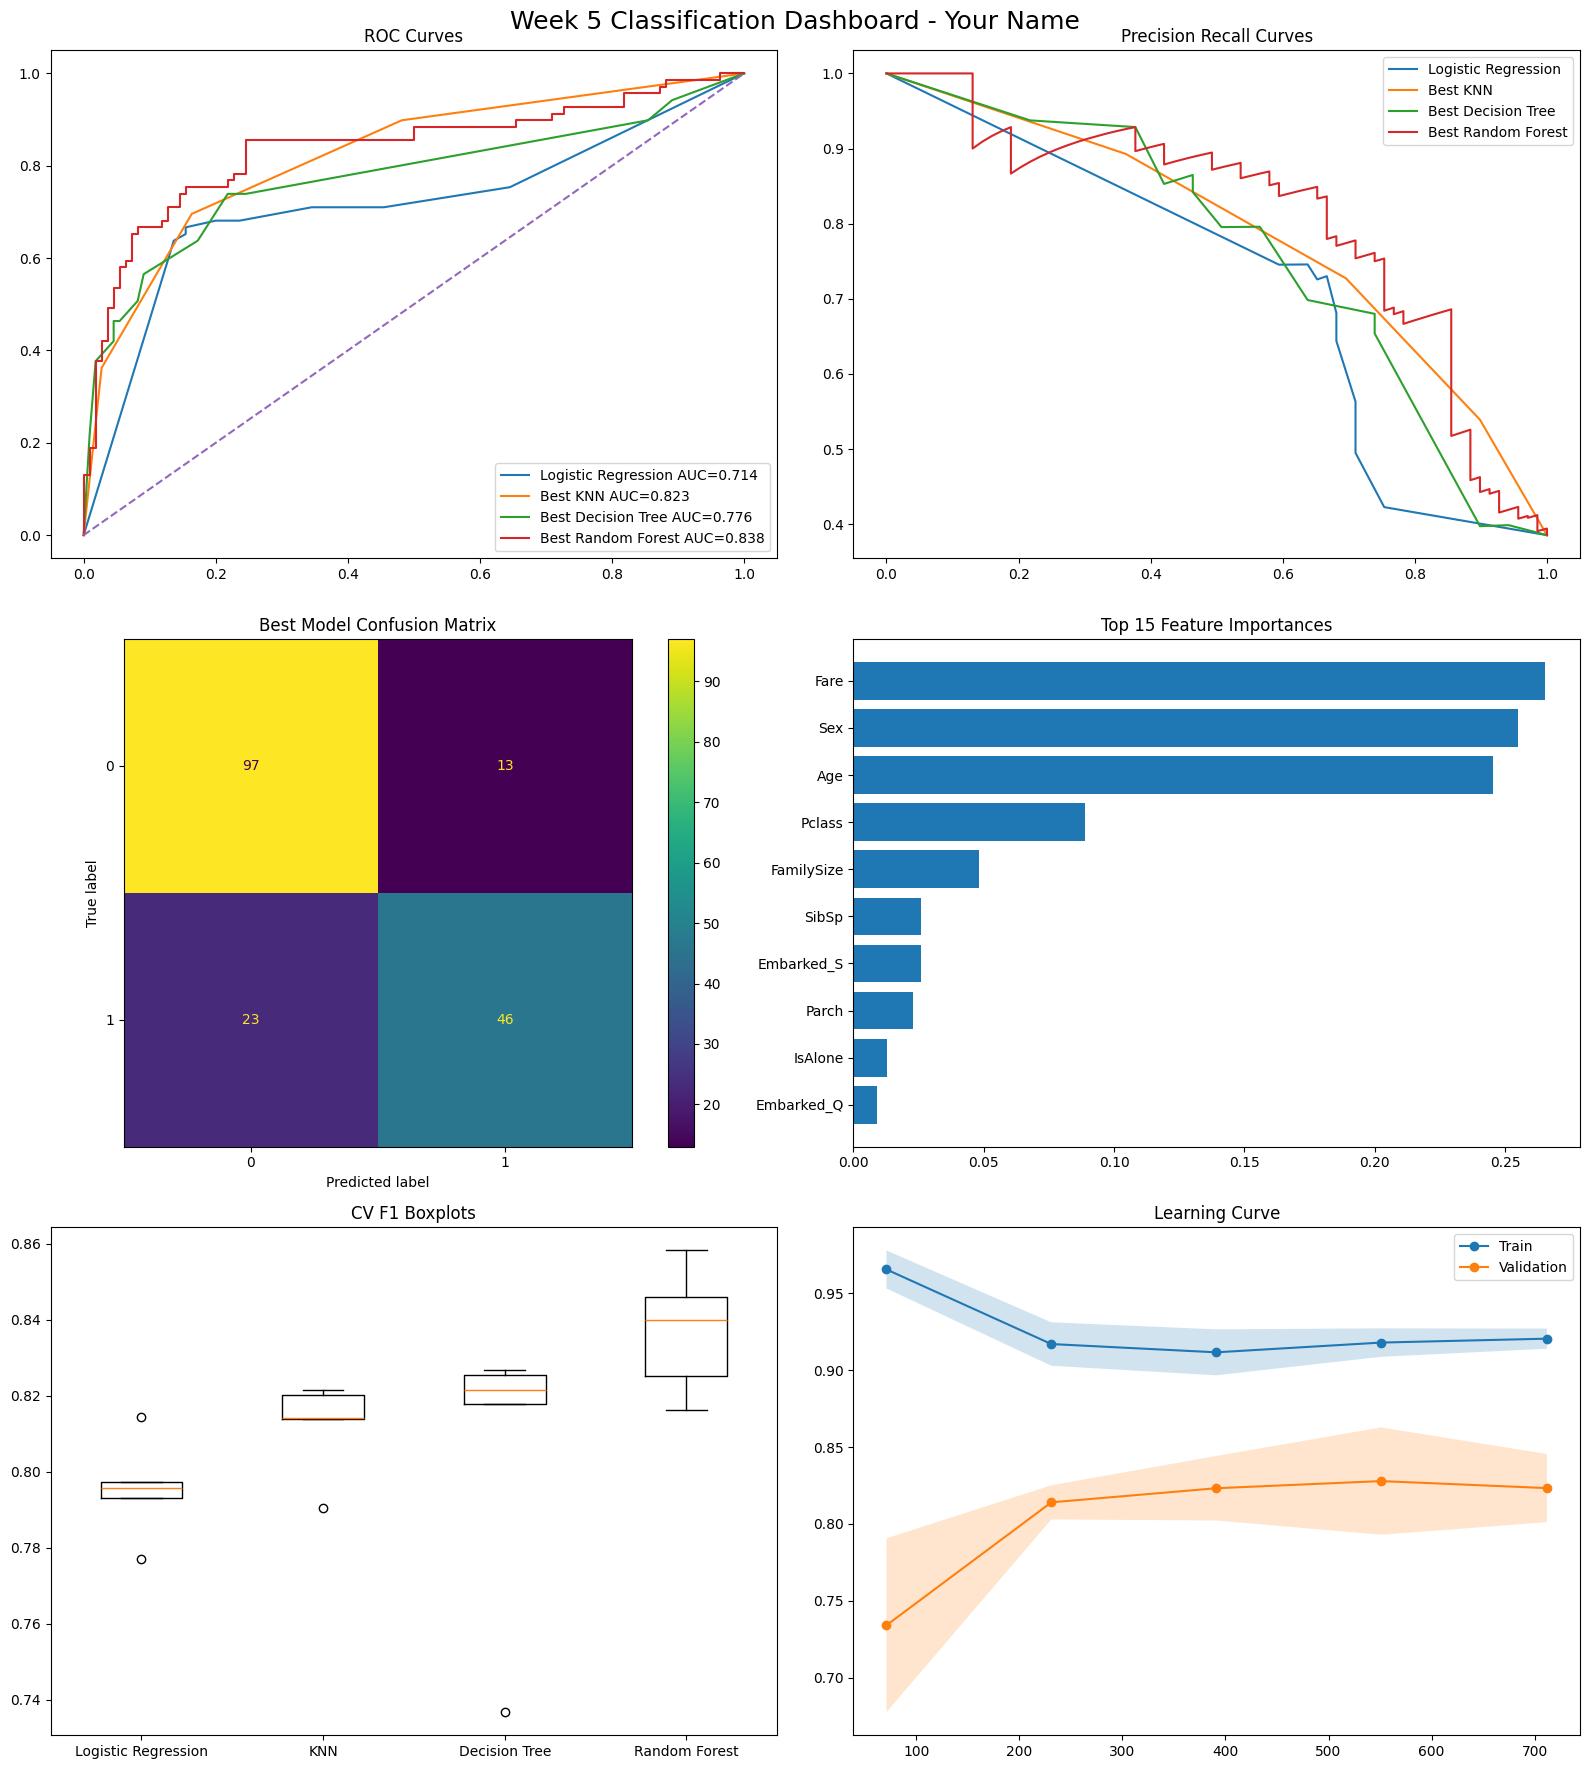

In [36]:
from sklearn.model_selection import learning_curve

best_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", best_rf_model)
])

best_pipeline.fit(X_train, y_train)

fig, ax = plt.subplots(3, 2, figsize=(16, 18))

fig.suptitle(
    "Week 5 Classification Dashboard - Your Name",
    fontsize=18
)

# ROC Curves

for name, clf in models.items():

    clf.fit(X_train_scaled, y_train)

    y_prob = clf.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    ax[0, 0].plot(
        fpr,
        tpr,
        label=f"{name} AUC={auc:.3f}"
    )

ax[0, 0].plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

ax[0, 0].set_title("ROC Curves")

ax[0, 0].legend()

# Precision Recall Curves

for name, clf in models.items():

    y_prob = clf.predict_proba(X_test_scaled)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    ax[0, 1].plot(
        recall,
        precision,
        label=name
    )

ax[0, 1].set_title("Precision Recall Curves")

ax[0, 1].legend()

# Confusion Matrix

cm = confusion_matrix(
    y_test,
    best_rf_model.predict(X_test_scaled)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(ax=ax[1, 0])

ax[1, 0].set_title("Best Model Confusion Matrix")

# Feature Importance

top_features = rf_importance.head(15)

ax[1, 1].barh(
    top_features["Feature"],
    top_features["Importance"]
)

ax[1, 1].invert_yaxis()

ax[1, 1].set_title("Top 15 Feature Importances")

# CV F1 Boxplot

ax[2, 0].boxplot(
    cv_f1_scores.values(),
    labels=cv_f1_scores.keys()
)

ax[2, 0].set_title("CV F1 Boxplots")

# Learning Curve

train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline,
    X,
    y,
    cv=5,
    scoring="f1_weighted",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)

train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)

val_std = val_scores.std(axis=1)

ax[2, 1].plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Train"
)

ax[2, 1].fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

ax[2, 1].plot(
    train_sizes,
    val_mean,
    marker="o",
    label="Validation"
)

ax[2, 1].fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

ax[2, 1].set_title("Learning Curve")

ax[2, 1].legend()

plt.tight_layout()

plt.savefig(
    "week5_dashboard.png",
    dpi=150
)

plt.show()

In [37]:
import joblib

y_pred = best_pipeline.predict(X_test)

y_prob = best_pipeline.predict_proba(X_test)[:, 1]

results_df = pd.DataFrame({
    "index": X_test.index,
    "actual_survived": y_test.values,
    "predicted_survived": y_pred,
    "correct": y_test.values == y_pred,
    "predicted_probability": np.max(
        best_pipeline.predict_proba(X_test),
        axis=1
    )
})

print(results_df.head())

   index  actual_survived  predicted_survived  correct  predicted_probability
0    565                0                   0     True               0.823512
1    160                0                   0     True               0.850588
2    553                1                   0    False               0.885874
3    860                0                   0     True               0.945486
4    241                1                   1     True               0.660882


In [38]:
wrong_predictions = results_df[
    results_df["correct"] == False
]

wrong_predictions = wrong_predictions.sort_values(
    by="predicted_probability",
    ascending=False
)

top_wrong = wrong_predictions.head(10)

print(top_wrong)

     index  actual_survived  predicted_survived  correct  \
92     570                1                   0    False   
168    199                0                   1    False   
99     271                1                   0    False   
53      17                1                   0    False   
139    444                1                   0    False   
150    804                1                   0    False   
84     501                0                   1    False   
28     455                1                   0    False   
2      553                1                   0    False   
112    146                1                   0    False   

     predicted_probability  
92                0.960843  
168               0.943511  
99                0.942448  
53                0.940029  
139               0.932886  
150               0.932850  
84                0.923784  
28                0.894590  
2                 0.885874  
112               0.871423  


In [39]:
joblib.dump(
    best_pipeline,
    "week5_best_model.pkl"
)

loaded_model = joblib.load(
    "week5_best_model.pkl"
)

sample_prediction = loaded_model.predict(
    X_test.iloc[:1]
)

print("Reloaded Model Prediction:")
print(sample_prediction)

Reloaded Model Prediction:
[0]


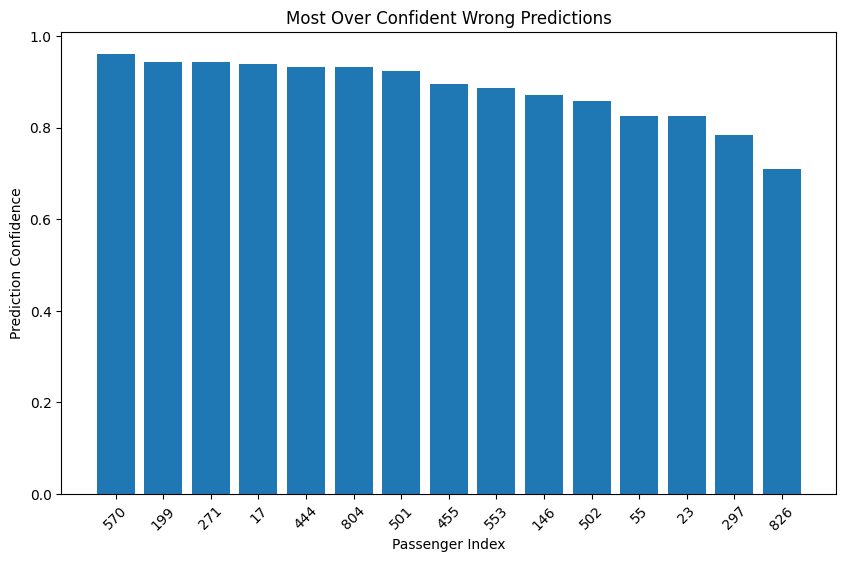

In [40]:
top_15_wrong = wrong_predictions.head(15)

plt.figure(figsize=(10, 6))

plt.bar(
    top_15_wrong["index"].astype(str),
    top_15_wrong["predicted_probability"]
)

plt.xticks(rotation=45)

plt.ylabel("Prediction Confidence")

plt.xlabel("Passenger Index")

plt.title("Most Over Confident Wrong Predictions")

plt.show()

### Over-Confident Misclassifications

The most confident wrong predictions were cases where the model assigned very high probability to the incorrect class.

This usually happens because some passengers had feature patterns strongly associated with survival or non-survival, causing the model to become overly confident even when exceptions existed in the real data.

Complex relationships, noisy patterns, and overlapping feature distributions can lead to confident misclassifications.

# 1. Executive Summary

In this project, multiple classification models were trained and evaluated on the Titanic survival dataset. The models included Logistic Regression, K-Nearest Neighbours, Decision Tree, and Random Forest. Different preprocessing and feature engineering techniques were applied, including missing value handling, encoding categorical variables, feature scaling, FamilySize creation, IsAlone creation, and Fare transformation using log1p. Model performance was evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC, confusion matrices, ROC curves, and cross-validation. Among all models, Random Forest achieved the best overall performance with the highest F1-score and ROC-AUC. Cross-validation results also showed that Random Forest generalized well and maintained strong predictive consistency across folds.

# 2. Feature Engineering Impact

Feature engineering significantly improved model performance. Creating FamilySize and IsAlone helped the models capture passenger social structure and travel behavior. Encoding Sex provided one of the strongest predictive variables because survival rates differed greatly between males and females. Applying log1p transformation to Fare reduced skewness and stabilized feature distribution, helping the models learn more effectively. Filling missing Age values with the median prevented information loss while maintaining data consistency. One-hot encoding of Embarked allowed models to learn location-based survival patterns. Feature importance analysis consistently showed that Sex, Pclass, Fare, and Age were the most influential variables across multiple models.

# 3. Model-by-Model Analysis

Logistic Regression was selected as the baseline model because it is simple, interpretable, and performs well on binary classification problems. The model used max_iter=1000 to ensure convergence. It produced stable results with balanced Precision and Recall, although it could not capture highly complex relationships. KNN was trained with multiple K values to identify the optimal neighborhood size. Smaller K values caused overfitting while larger K values reduced model flexibility. GridSearchCV identified the best K value using cross-validation. KNN performed better than Logistic Regression but required scaled features for effective distance calculations.

Decision Tree models were trained with different depths to study overfitting behavior. Small depths underfit the data while larger depths memorized training examples. GridSearchCV selected the best depth using F1-score optimization. Feature importance analysis showed that Sex and Pclass dominated survival decisions. However, Decision Trees showed higher variance across cross-validation folds, indicating instability.

Random Forest combined multiple Decision Trees to reduce overfitting and improve generalization. Different values of n_estimators were tested to analyze performance improvements. Increasing the number of trees improved stability and accuracy until performance gains became minimal. Hyperparameter tuning further optimized Random Forest performance. This model achieved the best F1-score and ROC-AUC because ensemble learning captured complex feature interactions while reducing variance and overfitting.

# 4. Regularization Insights

Ridge and Lasso regularization were analyzed using coefficient path plots across multiple alpha values. Ridge regularization shrinks coefficients gradually but rarely forces them exactly to zero. This helps reduce overfitting while keeping all features in the model. Lasso regularization applies stronger feature selection by shrinking some coefficients exactly to zero, effectively removing less useful variables. In this project, features such as Parch, Embarked_Q, and SibSp were among the first to approach zero, indicating lower predictive contribution. This makes practical sense because these features had weaker relationships with survival compared to dominant features such as Sex, Pclass, and Fare. Regularization helps improve generalization and prevents models from relying too heavily on noisy or weak predictors.

# 5. Residual Analysis Findings

Residual analysis showed that classification residuals were not perfectly normally distributed, which is expected in binary classification tasks. The residual plots did not show strong systematic patterns, indicating that the model captured the main relationships reasonably well. Histogram and Q-Q plots revealed deviations from normality because predictions were limited to discrete classes. The Scale-Location plot showed some variation in residual spread, but no severe heteroscedasticity was observed. The Shapiro-Wilk test produced a low p-value, confirming that residuals were not normally distributed. Since Random Forest is a non-linear ensemble model, strict linear regression assumptions are not required for strong predictive performance.

# 6. Best Model Recommendation

Random Forest is the recommended model for deployment because it achieved the highest F1-score, ROC-AUC, and cross-validation performance among all evaluated classifiers. It handled non-linear relationships effectively and reduced overfitting through ensemble averaging. From a business perspective, Random Forest provides more reliable survival predictions and better generalization on unseen data. The model also demonstrated strong stability across multiple validation folds. Although Logistic Regression offered better interpretability, Random Forest produced significantly stronger predictive performance, making it more suitable for practical classification tasks where accuracy and robustness are critical.

# 7. Reflection

One of the most challenging concepts in this project was understanding the trade-off between bias and variance across different models. Analyzing overfitting behavior in Decision Trees and selecting optimal hyperparameters using cross-validation required careful experimentation. The biggest surprise was how strongly the Sex feature influenced survival predictions across all models. Feature engineering also had a larger impact than expected, especially the creation of FamilySize and IsAlone. If given more time, additional ensemble methods such as XGBoost and Gradient Boosting would be explored to further improve predictive performance and compare advanced boosting techniques with Random Forest.